<a href="https://colab.research.google.com/github/BernardoBib/Conversao-Eletromecanica-Python/blob/main/Q2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Bibliotecas necessarias e constantes

from matplotlib import pyplot as plt
import matplotlib as mpl
import numpy as np
import scipy as sp
import sympy as smp
from scipy.interpolate import interp1d
from scipy.integrate import cumulative_trapezoid, trapezoid

#constantes
pi = np.pi
mu_0 = 4 * pi * 1e-7 #H/m

#Configurações Matplotlib

mpl.style.use("ggplot")

In [ ]:
#Parametros da questao

Hc = np.array ([ 0, 68, 135, 203, 271, 338, 406, 474, 542, 609, 1100, 1500, 2500, 4000, 5000, 9000, 12000, 20000, 25000 ]) # H[A/m]
Bc = np.array ([ 0, 0.733, 1.205, 1.424, 1.517, 1.560, 1.588, 1.617, 1.631, 1.646, 1.689, 1.703, 1.724, 1.731, 1.738, 1.761, 1.770, 1.8, 1.816 ]) # B[T]

g = 0.45e-3 # g[m]
r = 6.3e-2 #Raio do rotor[m]
D = 8e-2 #Comprimento do sistema[m]
N = 90 #e
lc = 75e-2 #Comprimento médio do sistema
theta_r = 30 #Comprimento angular do rotor e estator [graus]

n_pontos = 1000

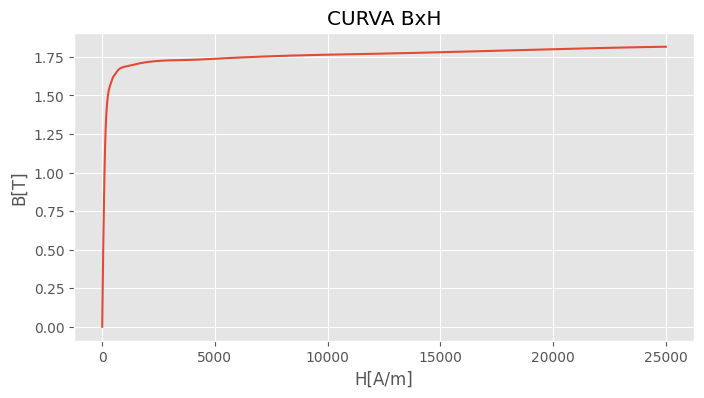

In [ ]:
#Curva BxH

y_int = sp.interpolate.interp1d(Hc, Bc, "cubic")
x_int = np.linspace(0, 25000, n_pontos)

fig1, axes1 = plt.subplots(1, 1, figsize = (8, 4))

axes1.plot(x_int, y_int (x_int))
axes1.set_ylabel("B[T]")
axes1.set_xlabel("H[A/m]")
plt.title("CURVA BxH")
plt.show()

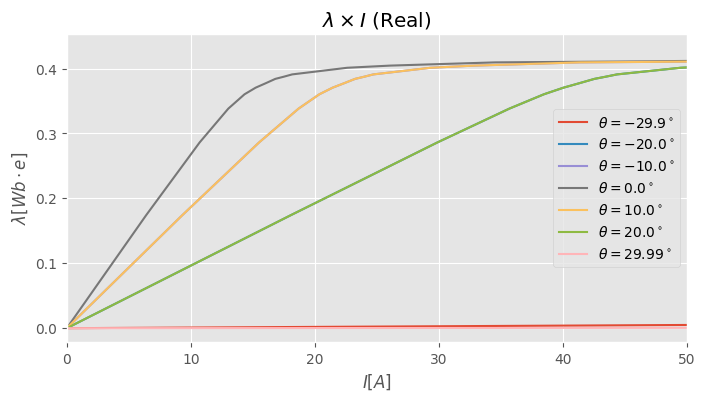

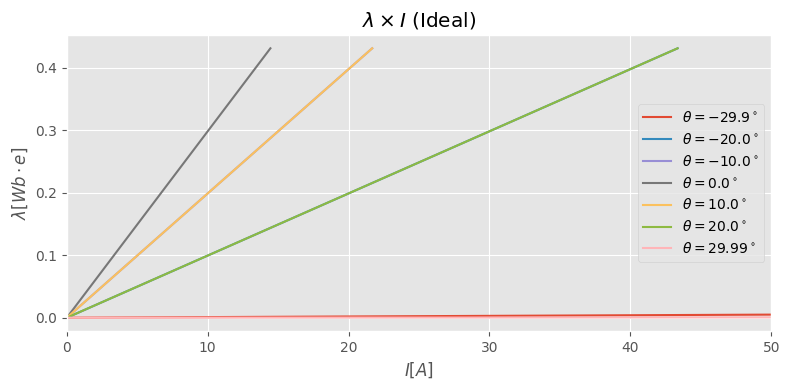

In [ ]:

# Plot de λ x I para os casos real e ideal

def area(theta):
    return D * 2 * pi * r * ((theta_r - abs(theta)) / 360)

# CÁLCULO DAS ÁREAS

Ac = D * 2 * pi * r * (theta_r / 360)

Ad = area(0)

theta_array = np.array([ -29.9, -20, -10, 0, 10, 20, 29.99])


# CONFIGURAÇÃO DAS FIGURAS

fig2, axes2 = plt.subplots(1, 1, figsize = (8, 4))
fig3, axes3 = plt.subplots(1, 1, figsize = (8, 4))


# LOOP PARA CADA POSIÇÃO DO ROTOR

for theta in theta_array:

    Ag = D * 2 * pi * r * ((theta_r - abs(theta)) / 360)


    if Ag <= 0:
        continue

    fluxo_conc = N * Bc * Ac

    B_g = (Bc * Ac) / Ag

    I_real = (Hc * lc + (B_g * 2 * g) / mu_0) / N

    I_ideal = ((B_g * 2 * g) / mu_0) / N

    # Plota as curvas λ x I para cada posição do rotor
    axes2.plot(I_real, fluxo_conc, label = rf"$\theta = {theta}^\circ$")
    axes3.plot(I_ideal, fluxo_conc, label = rf"$\theta = {theta}^\circ$")


# FORMATAÇÃO DOS GRÁFICOS


axes2.set_xlim(0,50)
axes3.set_xlim(0,50)


axes2.set_title(r"$\lambda \times I$ (Real)")
axes2.set_ylabel(r"$\lambda[Wb \cdot e]$") # Unidade para fluxo concatenado (Weber-espira)
axes2.set_xlabel(r"$I[A]$")
axes2.legend()
axes2.grid(True)


axes3.set_title(r"$\lambda \times I$ (Ideal)")
axes3.set_ylabel(r"$\lambda[Wb \cdot e]$") # Unidade para fluxo concatenado
axes3.set_xlabel(r"$I[A]$")
axes3.legend()
axes3.grid(True)


plt.tight_layout()
plt.show()

In [ ]:
# Cálculo das correntes para densidade de fluxo [B = 1.8T]
B_g = (1.8*Ac) / (area(0))
I1_8_real = ((20000 * lc + (B_g*2*g)/mu_0)/N)
I1_8_ideal = (((B_g*2*g)/mu_0)/N)
# Realizando o print formatado
print(f"Corrente Real (I1_8_real):  {I1_8_real:.2f} A")
print(f"Corrente Ideal (I1_8_ideal): {I1_8_ideal:.2f} A")

# Diferença entre elas (queda de tensão magnética no núcleo)
print(f"Diferença devido ao núcleo: {I1_8_real - I1_8_ideal:.2f} A")

Corrente Real (I1_8_real):  180.99 A
Corrente Ideal (I1_8_ideal): 14.32 A
Diferença devido ao núcleo: 166.67 A


In [ ]:
# calculo da energia magnetica em funcao da posicao do rotor

theta_array2 = np.linspace(-29.9, 29.9, n_pontos)

#corrente usada: I1_8_real
#Núcleo ideal: Hc * Ic = 0

#Fazer energia dependendo do theta

energia_real = []
energia_ideal = []

for theta in theta_array2:

    fluxo_conc2 = N * Bc * Ac
    B_g = (Bc * Ac) / area(theta)

    I_real2 = ((Hc*lc + (B_g*2*g)/mu_0) / N)
    I_ideal2 = np.ones(len(Hc)) * (((B_g*2*g)/mu_0) / N)

    I_bobina = np.linspace(0, I1_8_real, n_pontos)

    fxI_real = sp.interpolate.interp1d(I_real2, fluxo_conc2, "cubic", fill_value="extrapolate")
    fxI_ideal = sp.interpolate.interp1d(I_ideal2, fluxo_conc2, "cubic", fill_value="extrapolate")

    energia_real.append(sp.integrate.trapezoid(fxI_real(I_bobina), I_bobina))
    energia_ideal.append(sp.integrate.trapezoid(fxI_ideal(I_bobina), I_bobina))


In [ ]:
# conversao para array's e calculo do torque

energia_real = np.array(energia_real)
energia_ideal = np.array(energia_ideal)

theta_rad = np.deg2rad(theta_array2)

torque_real = np.gradient(energia_real, theta_rad)
torque_ideal = np.gradient(energia_ideal, theta_rad)

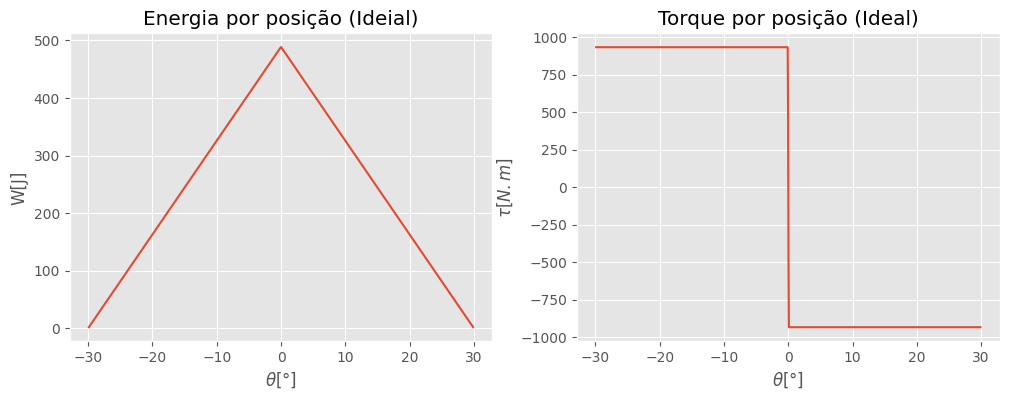

In [ ]:
# graficos de energia e torque para caso ideal

fig4, axes4 = plt.subplots(1, 2, figsize = (12, 4))

axes4[0].plot(theta_array2, energia_ideal)
axes4[0].set_title("Energia por posição (Ideial)")
axes4[0].set_ylabel("W[J]")
axes4[0].set_xlabel(r"$\theta[°]$")

axes4[1].plot(theta_array2, torque_ideal)
axes4[1].set_title("Torque por posição (Ideal)")
axes4[1].set_ylabel(r"$\tau[N.m]$")
axes4[1].set_xlabel(r"$\theta[°]$")

plt.show()

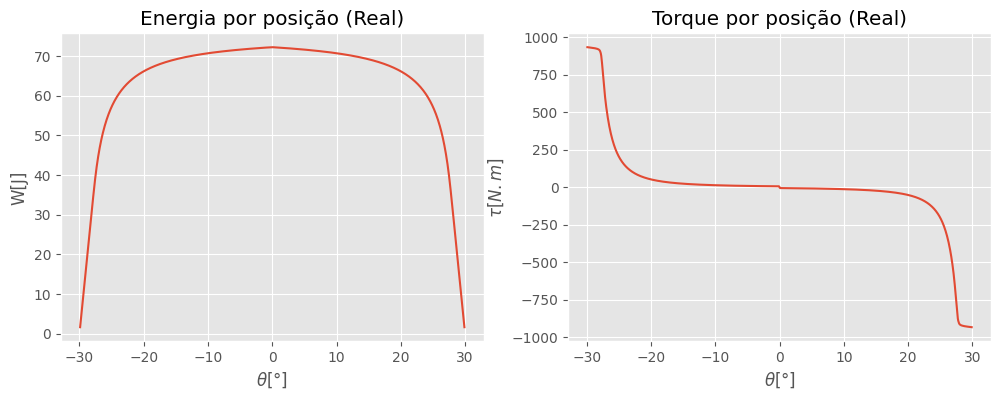

In [ ]:
# graficos de energia e torque para caso real

fig5, axes5 = plt.subplots(1, 2, figsize = (12, 4))

axes5[0].plot(theta_array2, energia_real)
axes5[0].set_title("Energia por posição (Real)")
axes5[0].set_ylabel("W[J]")
axes5[0].set_xlabel(r"$\theta[°]$")

axes5[1].plot(theta_array2, torque_real)
axes5[1].set_title("Torque por posição (Real)")
axes5[1].set_ylabel(r"$\tau[N.m]$")
axes5[1].set_xlabel(r"$\theta[°]$")

plt.show()

In [ ]:
# calculo da razao de potencias
# Ideal (Não importa o angulo)

fluxo_conc3 = N*Bc*Ac
B_g = (Bc*Ac)/(area(10))
I_real3 = ((Hc*lc + (B_g*2*g)/mu_0)/N)
I_ideal3 = np.ones(len(Hc))*(((B_g*2*g)/mu_0)/N)

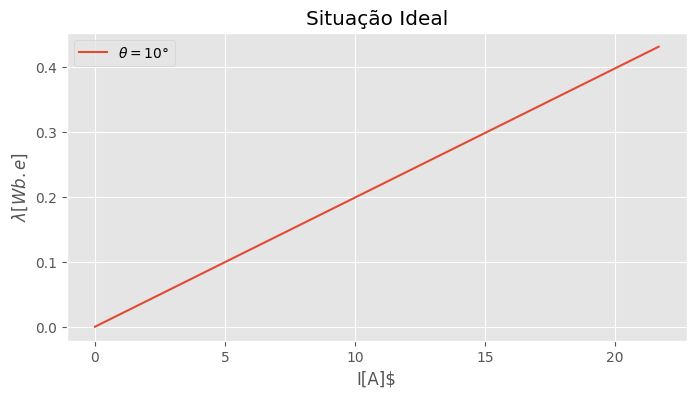

In [ ]:
# # Plot de λ x I para o calculo de potencia (situacao ideal)

fig6, axes6 = plt.subplots (1, 1, figsize = (8, 4))

axes6.set_title("Situação Ideal")
axes6.set_ylabel(r"$\lambda[Wb.e]$")
axes6.set_xlabel(r"I[A]$")
axes6.plot(I_ideal3, fluxo_conc3, label = r"$\theta = 10°$")
axes6.legend()
plt.show()

In [ ]:
# calculo da razao de potencia ideal

P_ac_ideal = max(fluxo_conc3) * max(I_ideal3)
P_motor_ideal = sp.integrate.trapezoid(I_ideal3, fluxo_conc3)

razaoP_ideal = P_motor_ideal/P_ac_ideal
print(f"Razão de Potência ideal = {razaoP_ideal:.2%}")

Razão de Potência ideal = 50.00%


In [ ]:
# calculo da razao de potencia no caso real para angulos definidos

angulos = [0, 5, 10, 15, 20, 25, 29.9]

fluxo_conc3 = N*Bc*Ac
for ang in angulos:
    B_g = (Bc*Ac)/(area(ang))
    I_real3 = ((Hc*lc + (B_g*2*g)/mu_0)/N)
    I_ideal3 = np.ones(len(Hc))*(((B_g*2*g)/mu_0)/N)

    area_cima = sp.integrate.trapezoid(fluxo_conc3, I_real3)
    area_baixo = sp.integrate.trapezoid(I_real3, fluxo_conc3)

    P_ac_real = area_cima + area_baixo
    P_motor_real = area_cima
    razaoP_real = P_motor_real/P_ac_real

    print(f"Theta = {ang}: Razão Real = {razaoP_real:.2%}")



Theta = 0: Razão Real = 93.81%
Theta = 5: Razão Real = 93.25%
Theta = 10: Razão Real = 92.43%
Theta = 15: Razão Real = 91.14%
Theta = 20: Razão Real = 88.78%
Theta = 25: Razão Real = 83.08%
Theta = 29.9: Razão Real = 52.15%
